<a href="https://colab.research.google.com/github/mykytenko007/NM/blob/main/%D0%9B%D1%80%E2%84%963_2_%D0%9C%D0%B8%D0%BA%D0%B8%D1%82%D0%B5%D0%BD%D0%BA%D0%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Тема: Відокремлення дійсних коренів рівнянь та їх уточнення методом простої ітерації.

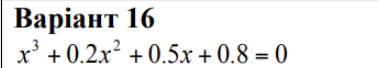

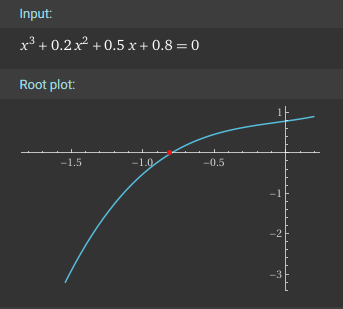

Корінь належить відрізку [−1;0]

In [ ]:
!pip install numdifftools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 2.0 MB/s eta 0:00:00


In [ ]:
import numdifftools as nd

In [ ]:
import numdifftools as nd

def f(x: float):
    return x**3 + 0.2*x**2 + 0.5*x + 0.8

def fprime(x: float):
    return nd.Derivative(f, n=1)(x)

def phi(x: float):
    c = -0.1
    return x + c * f(x)

def iterate_fixed_point(x0: float, iters: int = 5):
    xs = [x0]
    x = x0
    for _ in range(iters):
        x = phi(x)
        xs.append(x)
    return xs

def error_bound(x_last: float) -> float:
    mu = 0.5
    return abs(f(x_last)) / mu

x0 = -1.0

xs = iterate_fixed_point(x0, 5)

for i, x in enumerate(xs):
    print(f"x{i} = {x:.6f}")

print(f"\nОцінка похибки: {error_bound(xs[-1]):.6f}")

x0 = -1.000000
x1 = -0.950000
x2 = -0.914812
x3 = -0.889251
x4 = -0.870284
x5 = -0.856003

Оцінка похибки: 0.217364


In [ ]:
def main():
    x0 = -1.0

    iters = 5
    xs = iterate_fixed_point(x0, iters)

    print("Fixed-point iteration for f(x) = x^3 + 0.2x^2 + 0.5x + 0.8")
    print("with phi(x) = x - 0.1*f(x)")
    print(f"Interval: [-1, 0], start x0 = {x0}")

    for i, xi in enumerate(xs):
        if i == 0:
            print(f"x_{i} = {xi:.10f}")
        else:
            print(f"x_{i} = phi(x_{i-1}) = {xi:.10f}")

    bound = error_bound(xs[-1])

    print("\nError bound after 5 iterations:  |ξ - x5| ≤ |f(x5)| / μ")
    print(f"f(x5) = {f(xs[-1]):.10f},  μ = 0.5  ⇒  |ξ - x5| ≤ {bound:.10f}")

    return xs[-1], bound


if __name__ == "__main__":
    root_approx, bound = main()

Fixed-point iteration for f(x) = x^3 + 0.2x^2 + 0.5x + 0.8
with phi(x) = x - 0.1*f(x)
Interval: [-1, 0], start x0 = -1.0
x_0 = -1.0000000000
x_1 = phi(x_0) = -0.9500000000
x_2 = phi(x_1) = -0.9148125000
x_3 = phi(x_2) = -0.8892505100
x_4 = phi(x_3) = -0.8702843652
x_5 = phi(x_4) = -0.8560031526

Error bound after 5 iterations:  |ξ - x5| ≤ |f(x5)| / μ
f(x5) = -0.1086822429,  μ = 0.5  ⇒  |ξ - x5| ≤ 0.2173644858
